# 2 - FM IQ Modulator

Dieses Notebook erzeugt ein komplexes FM-Signal im Zero-IF, mischt es mit einem komplexen LO auf Low-IF, analysiert das Spektrum und bietet am Ende ein Hör-Feedback.

**Hinweis:**  
**IF** steht für *Intermediate Frequency*, auf Deutsch "Zwischenfrequenz", und **Zero-IF** bedeutet, dass diese Zwischenfrequenz bei Null Hertz liegt.
Der Begriff **Zwischenfrequenz** bedeutet auch, dass es sich noch nicht um die endgültige Sendefrequenz handelt.

## Überblick und Formeln (I/Q-Generierung)

Basisbandsignal:
$$u_m(t)=U_m\cos(2\pi f_m t + \varphi_m)$$

Normierung des Basisbandsignals:
$$\hat u_m(t)=\frac{u_m(t)}{\max|u_m(t)|}$$

FM-Phasenverlauf bei Trägerfrequenz Null (Zero-IF)
$$\varphi_{bb}(t)=2\pi\Delta f\int_0^t\hat u_m(\tau)\,d\tau+\varphi_c$$

Komplexes FM-IQ-Signal:
$$z_{FM}(t)=U_c\,e^{j\varphi_{bb}(t)}=I_{FM}(t)+jQ_{FM}(t)$$
$$I_{FM}(t)=\Re\{z_{FM}(t)\},\quad Q_{FM}(t)=\Im\{z_{FM}(t)\}$$

Komplexer LO:
$$z_{LO}(t)=\cos(2\pi f_{LO}t+\varphi_{LO})+j\sin(2\pi f_{LO}t+\varphi_{LO})$$

Komplexe Mischung:
$$z_{mix}(t)=z_{FM}(t)\cdot z_{LO}(t)$$
$$I_{mix}(t)=\Re\{z_{mix}(t)\},\quad Q_{mix}(t)=\Im\{z_{mix}(t)\}$$

## Parameter und Vorbereitung

Wir definieren Beobachtungsdauer, Abtastrate, FM-/LO-Parameter und Zeitachse.

**Wichtiger Hinweis:** In diesem Notebook wird das FM-Signal zuerst als **Zero-IF-IQ**-Signal erzeugt. Die finale Mittenfrequenz nach der Frequenzverschiebung auf eine Trägerfrequenz ungliech Null (Mischung) wird vollständig durch `f_lo` festgelegt.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Audio, display

# Beobachtungs- und Abtastparameter
T_obs = 1                # Beobachtungsdauer des Signals [s]
fs = 200_000               # Abtastrate [Hz]
N_sig = int(T_obs * fs)    # Anzahl Samples im Zeitsignal [-]
N_fft = 16384              # FFT-Länge für Spektralanalyse [-]

# Optionale FFT-Fensterung zur Leakage-Reduktion
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'   # Fensterart: 'hann' | 'hamming' | 'rect'

# FM-Signalparameter
U_c = 1.0                  # komplexe Träger-/Hüllkurven-Amplitude [-]
f_m = 880.0                # Basisband-/Modulationsfrequenz [Hz]
U_m = 1.0                  # Basisbandamplitude [-]
phi_c_deg = 0.0            # Startphase des FM-Trägers [deg]
phi_m_deg = 0.0            # Startphase des Basisbands [deg]
delta_f = 1_000.0          # Frequenzhub der FM [Hz]

# Komplexer Mischer (Umsetzung von Zero-IF auf Low-IF)
f_lo = -22_000.0           # LO-Frequenz [Hz], bestimmt die finale Mittenfrequenz des ausgegebenen Signals
phi_lo_deg = 0.0           # Startphase des LO [deg]
f_out_center_hz = f_lo     # erwartete Mittenfrequenz des Mischprodukts [Hz]

# Plot-/Visualisierungsparameter
t_plot_ms = 6.0            # dargestelltes Zeitfenster in Plots [ms]
t = np.arange(N_sig) / fs  # Zeitachse [s]
n_plot = min(N_sig, int(t_plot_ms * 1e-3 * fs))  # Anzahl gezeigter Samples [-]

# Winkel in Radiant (für trigonometrische Funktionen)
phi_c = np.deg2rad(phi_c_deg)
phi_m = np.deg2rad(phi_m_deg)
phi_lo = np.deg2rad(phi_lo_deg)

## 1) TODO: FM-IQ bei Zero-IF berechnen

Numerische Integration mit
$$INT_u=\int_0^t\hat u_m(\tau)d\tau \approx \frac{1}{f_s}\sum_k \hat u_m[k]$$
und danach das Zero-IF Signal $z_{FM}$
$$z_{FM}[n]=I_{FM}[n]+jQ_{FM}[n]=U_c\exp\left(j\left(2\pi\Delta f\int_0^{t_n}\hat u_m(\tau)d\tau+\varphi_c\right)\right)=U_c\exp\left(j\left(2\pi\Delta f.INT_u+\varphi_c\right)\right).$$

In [2]:
# Ersetze die Platzhalter-Werte gemäß der oben angegebenen Formeln
# Nachrichtensignal erzeugen
u_m = U_m * np.cos(2*np.pi*f_m*t + phi_m)

# Normierung
u_m_hat = u_m / np.max(np.abs(u_m))

# Numerische Integration
int_u = np.cumsum(u_m_hat) / fs

# FM-Phase bei Zero-IF
phi = 2 * np.pi * delta_f * int_u + phi_c

# Komplexes FM-IQ-Signal
z_fm = U_c * np.exp(1j * phi)

# I- und Q-Kanal
i_fm = np.real(z_fm)
q_fm = np.imag(z_fm)

# Modulationsindex
eta = delta_f / max(f_m, 1e-12)
print(f'FM-Modulationsindex eta = {eta:.3f}')

FM-Modulationsindex eta = 1.136


## 1a) I- und Q-Kanal von Zero-IF-FM darstellen

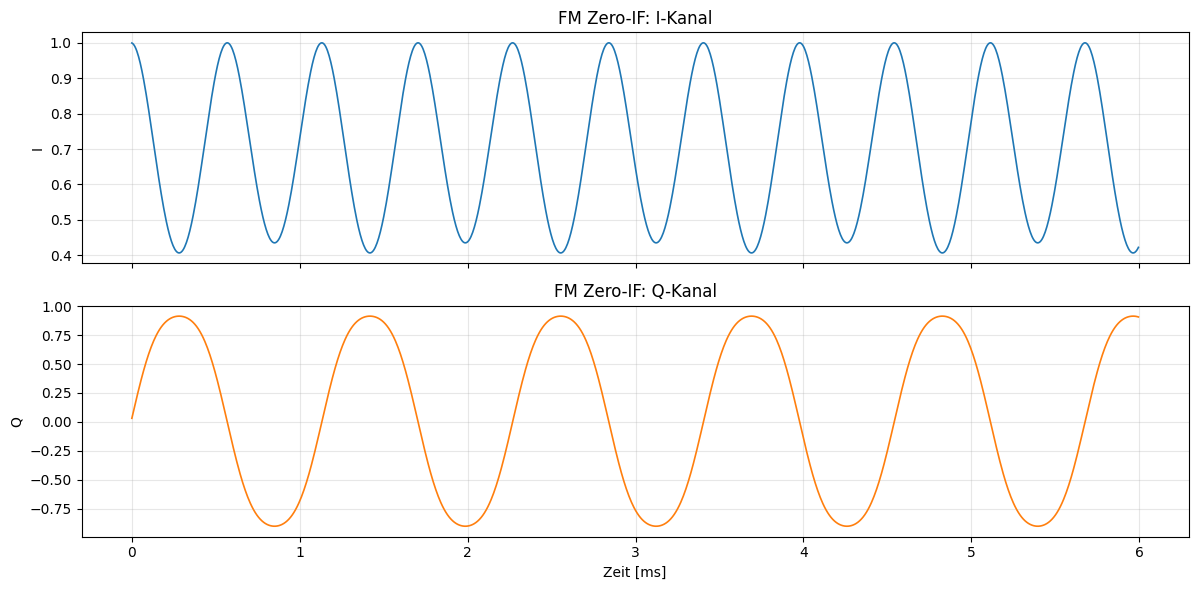

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[:n_plot]*1e3, i_fm[:n_plot], lw=1.2)
ax[0].set_title('FM Zero-IF: I-Kanal')
ax[0].set_ylabel('I')
ax[0].grid(alpha=0.3)

ax[1].plot(t[:n_plot]*1e3, q_fm[:n_plot], lw=1.2, color='tab:orange')
ax[1].set_title('FM Zero-IF: Q-Kanal')
ax[1].set_xlabel('Zeit [ms]')
ax[1].set_ylabel('Q')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 1b) IQ-Scatter in der komplexen Ebene

Darstellung von \(I\) gegen \(Q\) zur Visualisierung der komplexen Signaltrajektorie.
Wichtig: Die Achsen werden mit **1:1 Aspect Ratio** dargestellt, damit die Geometrie nicht verzerrt ist.

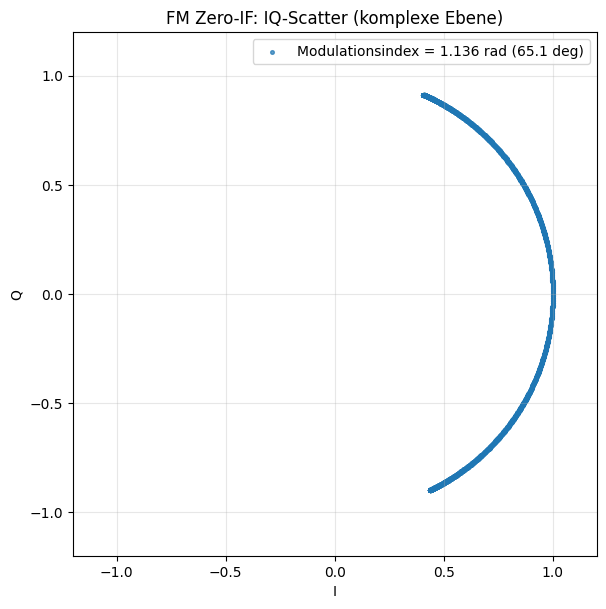

In [4]:
# Scatterplot: I/Q in der komplexen Ebene (1:1)
max_scatter = min(len(i_fm), int(0.02 * fs))  # bis zu 20 ms für übersichtlichen Plot

fig, ax = plt.subplots(figsize=(6.8, 6.8))
eta_deg = np.rad2deg(eta)
ax.scatter(
    i_fm[:max_scatter],
    q_fm[:max_scatter],
    s=7,
    alpha=0.7,
    label=f'Modulationsindex = {eta:.3f} rad ({eta_deg:.1f} deg)',
)
ax.set_title('FM Zero-IF: IQ-Scatter (komplexe Ebene)')
ax.set_xlabel('I')
ax.set_ylabel('Q')
ax.set_aspect('equal', adjustable='box')  # 1:1 Skalierung
ax.set_xlim(-1.2, 1.2)                    # fester I-Bereich (+20%)
ax.set_ylim(-1.2, 1.2)                    # fester Q-Bereich (+20%)
ax.grid(alpha=0.3)
ax.legend(loc='upper right')
plt.show()

## 2) Komplexen Lokaloszillator erzeugen

$$z_{LO}(t)=\cos(2\pi f_{LO}t+\varphi_{LO})+j\sin(2\pi f_{LO}t+\varphi_{LO}).$$

LO-Frequenz f_lo = -22000.0 Hz
Erwartete Ausgangsmittenfrequenz f_out_center = -22000.0 Hz


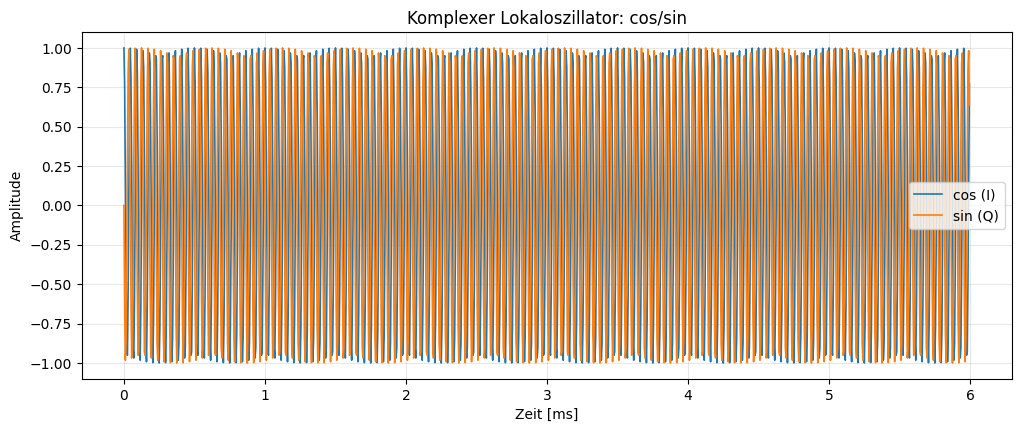

In [5]:
lo_i = np.cos(2*np.pi*f_lo*t + phi_lo)
lo_q = np.sin(2*np.pi*f_lo*t + phi_lo)
lo_cx = lo_i + 1j*lo_q

print(f'LO-Frequenz f_lo = {f_lo:.1f} Hz')
print(f'Erwartete Ausgangsmittenfrequenz f_out_center = {f_out_center_hz:.1f} Hz')

plt.figure(figsize=(12, 4.5))
plt.plot(t[:n_plot]*1e3, lo_i[:n_plot], lw=1.2, label='cos (I)')
plt.plot(t[:n_plot]*1e3, lo_q[:n_plot], lw=1.2, label='sin (Q)')
plt.title('Komplexer Lokaloszillator: cos/sin')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 3) Komplexe Mischung

$$z_{mix}(t)=z_{FM}(t)\cdot z_{LO}(t).$$

In [6]:
z_mix = z_fm * lo_cx
i_mix = np.real(z_mix)
q_mix = np.imag(z_mix)
print('Mischung abgeschlossen: z_mix = z_fm * (cos + j*sin)')

Mischung abgeschlossen: z_mix = z_fm * (cos + j*sin)


## 3a) I/Q des Mischprodukts darstellen

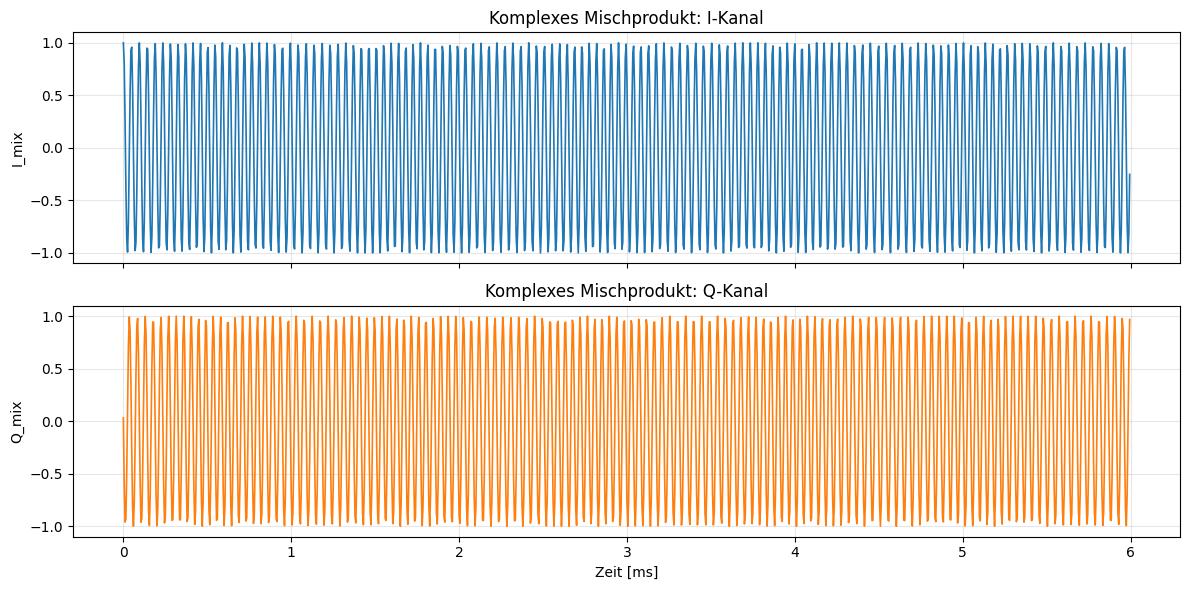

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[:n_plot]*1e3, i_mix[:n_plot], lw=1.2)
ax[0].set_title('Komplexes Mischprodukt: I-Kanal')
ax[0].set_ylabel('I_mix')
ax[0].grid(alpha=0.3)

ax[1].plot(t[:n_plot]*1e3, q_mix[:n_plot], lw=1.2, color='tab:orange')
ax[1].set_title('Komplexes Mischprodukt: Q-Kanal')
ax[1].set_xlabel('Zeit [ms]')
ax[1].set_ylabel('Q_mix')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4) Spektralanalyse (komplex, zweiseitig)

Wir berechnen jeweils
$$X[k]=\mathcal{F}\{x[n]\cdot w[n]\},\quad A[k]=\frac{|X[k]|}{N\cdot CG},\quad A_{dB}[k]=20\log_{10}(A[k]).$$

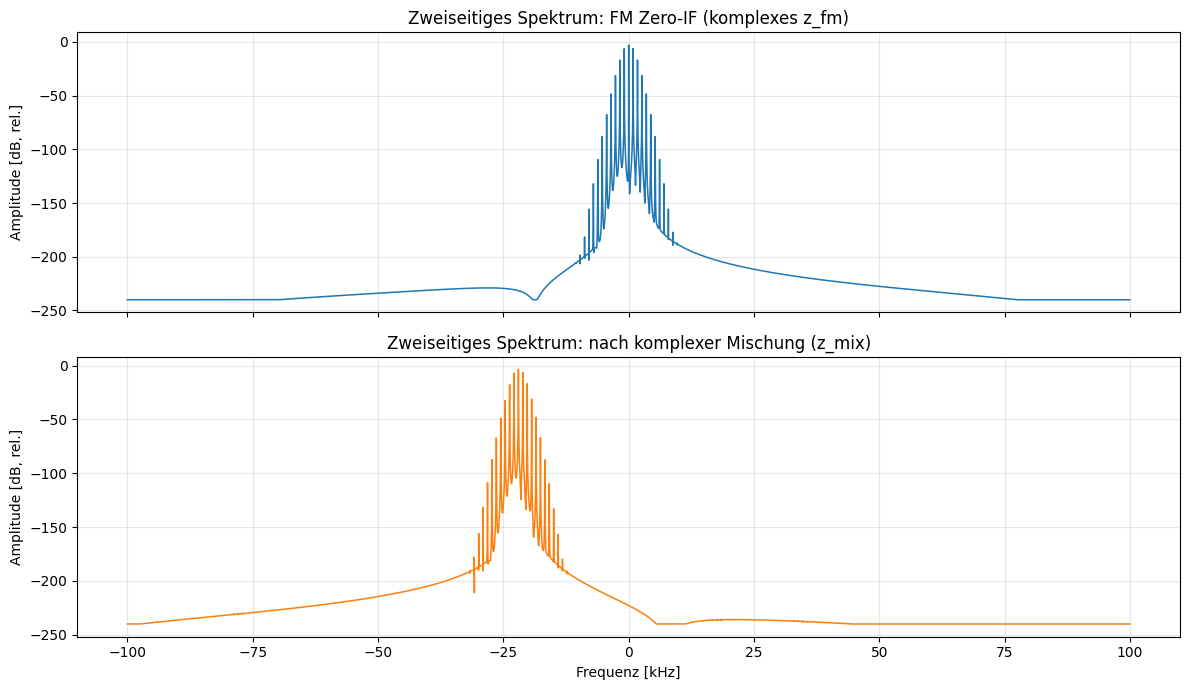

In [8]:
def _window(n: int, use_window: bool = True, kind: str = 'hann') -> np.ndarray:
    if not use_window:
        return np.ones(n)
    if kind == 'hann':
        return np.hanning(n)
    if kind == 'hamming':
        return np.hamming(n)
    return np.ones(n)


def spectrum_complex(x: np.ndarray, fs_hz: float, n_fft: int, use_window: bool, win_kind: str):
    x_pad = np.zeros(n_fft, dtype=np.complex128)
    n_copy = min(len(x), n_fft)
    x_pad[:n_copy] = x[:n_copy]

    w = _window(n_fft, use_window, win_kind)
    cg = np.mean(w)
    X = np.fft.fftshift(np.fft.fft(x_pad * w, n=n_fft))
    f = np.fft.fftshift(np.fft.fftfreq(n_fft, d=1/fs_hz))
    A = np.abs(X) / max(n_fft * cg, 1e-12)
    A_db = 20*np.log10(np.maximum(A, 1e-12))
    return f, A_db


f0, A0_db = spectrum_complex(z_fm, fs, N_fft, USE_FFT_WINDOW, FFT_WINDOW_KIND)
f1, A1_db = spectrum_complex(z_mix, fs, N_fft, USE_FFT_WINDOW, FFT_WINDOW_KIND)

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(f0/1e3, A0_db, lw=1.1)
ax[0].set_title('Zweiseitiges Spektrum: FM Zero-IF (komplexes z_fm)')
ax[0].set_ylabel('Amplitude [dB, rel.]')
ax[0].grid(alpha=0.3)

ax[1].plot(f1/1e3, A1_db, lw=1.1, color='tab:orange')
ax[1].set_title('Zweiseitiges Spektrum: nach komplexer Mischung (z_mix)')
ax[1].set_xlabel('Frequenz [kHz]')
ax[1].set_ylabel('Amplitude [dB, rel.]')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5) Save to file

Analog zum AM-Notebook speichern wir Signal und Metadaten als NumPy-Dateien.

In [9]:
out_name = 'FM-IQ-carrier.npy'
out_path = Path.cwd() / out_name

meta = {
    'fs_hz': float(fs),
    'f_lo_hz': float(f_lo),
    'f_m_hz': float(f_m),
    'delta_f_hz': float(delta_f),
    'eta': float(eta),
    'f_out_center_hz': float(f_out_center_hz),
    'phi_c_deg': float(phi_c_deg),
    'phi_m_deg': float(phi_m_deg),
    'phi_lo_deg': float(phi_lo_deg),
    'N_sig': int(N_sig),
    'signal_type': 'complex_fm_iq_mixed',
}

np.save(out_path, z_mix.astype(np.complex64))
np.save(out_path.with_name('FM-IQ-carrier-meta.npy'), meta, allow_pickle=True)

print(f'Gespeichert: {out_path}')
print(f'Gespeichert: {out_path.with_name("FM-IQ-carrier-meta.npy")}')
print('Laden im Folge-Notebook: z = np.load("FM-IQ-carrier.npy")')

Gespeichert: C:\Users\ralfk\GIT_KT\KT-course\lab_suite\labs\04_03_LABOR-5\submissions\FM-IQ-carrier.npy
Gespeichert: C:\Users\ralfk\GIT_KT\KT-course\lab_suite\labs\04_03_LABOR-5\submissions\FM-IQ-carrier-meta.npy
Laden im Folge-Notebook: z = np.load("FM-IQ-carrier.npy")


## 6) Hör-Feedback des hochgemischten Signals

Für eine akustische Schnellprüfung verwenden wir den Realteil von $z_{mix}(t)$, resamplen näherungsweise auf 48 kHz und wiederholen das Signal zyklisch.

In [10]:
fs_audio = 48_000
x_real = np.real(z_mix).astype(np.float64)

# einfache lineare Resampling-Näherung ohne Zusatzbibliothek
duration = len(x_real) / fs
n_audio = int(duration * fs_audio)
t_src = np.arange(len(x_real)) / fs
t_dst = np.arange(n_audio) / fs_audio
x_audio = np.interp(t_dst, t_src, x_real)

# DC entfernen + normieren
x_audio = x_audio - np.mean(x_audio)
x_audio = x_audio / max(np.max(np.abs(x_audio)), 1e-12)

# zyklisch wiederholen, damit mehrere Sekunden hörbar sind
repeat_sec = 4.0
rep = max(1, int(np.ceil((repeat_sec * fs_audio) / len(x_audio))))
x_audio_rep = np.tile(x_audio, rep)
x_audio_rep = x_audio_rep[:int(repeat_sec * fs_audio)]

print(f'Audio vorbereitet: Originaldauer {duration} sec  {len(x_audio_rep)} Samples @ {fs_audio} Hz, Dauer {len(x_audio_rep)/fs_audio:.2f} s')
display(Audio(x_audio_rep, rate=fs_audio))

Audio vorbereitet: Originaldauer 1.0 sec  192000 Samples @ 48000 Hz, Dauer 4.00 s
